# Sampling the Cube

<div class="page-subtitle">
Navigating multi dimensional data across space, time, and conditions
</div>

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HendrikWulf/sds210-jb/blob/main/book/12_L10_time-series/04_sampling_the_cube.ipynb)

---

```{admonition} Big idea
:class: tip

A data cube becomes analytically useful only once you can isolate the specific slice, region, or location required for a scientific question.
```

In the previous chapter, you learned how to ingest and visually verify a dataset. Now, we move from passive inspection to **active selection**. While conceptually a cube is a coherent structure of observations, its real power is unlocked when you can query it deliberately to solve scientific problems.

The shift in this chapter is fundamental: you will move away from "index guessing"—manually counting matrix positions—and toward a readable scientific workflow based on **named dimensions, coordinate labels, and conditions**. This approach makes your code easier to read, easier to debug, and much closer to the scientific questions you are actually asking.

We will progress from basic coordinate selection to advanced conditional masking and vectorized sampling using the `air_temperature` tutorial dataset.

In [3]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the tutorial dataset
ds = xr.tutorial.load_dataset("air_temperature")
air = ds["air"]

# Display the structure
ds

<xarray.Dataset> Size: 31MB
Dimensions:  (time: 2920, lat: 25, lon: 53)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Data variables:
    air      (time, lat, lon) float64 31MB 241.2 242.5 243.5 ... 296.2 295.7
Attributes:
    Conventions:  COARDS
    title:        4x daily NMC reanalysis (1948)
    description:  Data is from NMC initialized reanalysis\n(4x/day).  These a...
    platform:     Model
    references:   http://www.esrl.noaa.gov/psd/data/gridded/data.ncep.reanaly...

---

## 1. Why querying the cube matters

A data cube is powerful because it stores thousands (or millions) of observations in one aligned structure. However, that structure is only useful if we can ask targeted questions of it. In spatial data science, analysis is almost always selective by nature.

A scientist, planner, or analyst rarely asks to see the "full array." Instead, they "interrogate" the cube with questions involving specific constraints:

* **Temporal Patterns:** What was the air temperature on a specific morning in June 2013?
* **Local Trends:** How does the temperature at a specific weather station change through time?
* **Regional Summaries:** What is the mean value inside a specific administrative boundary or study area?
* **Condition-based Filtering:** Where in the region did the temperature exceed 30°C today?

Xarray provides the tools to move from a large, abstract cube to a small, interpretable subset that directly matches your research question. If the previous chapter taught you how to **read** the cube, this chapter teaches you how to **interrogate** it.

---

## 2. Position and label based selection

Xarray provides four distinct ways to index and select data. The most important distinction is between navigating by **physical matrix indices** and navigating by **coordinate values**. By using labeled dimensions, Xarray eliminates the mental overhead of remembering whether "axis 0" refers to time, latitude, or a specific sensor band.

### .isel for position based selection

The method `.isel` (integer selection) is the direct descendant of NumPy style indexing. It is **0-based** and allows you to select specific elements by their numerical position along a dimension.

In [4]:
# Select the first time step and specific row/column positions
# This returns a DataArray of a single point in time
air.isel(time=0, lat=2, lon=3)

<xarray.DataArray 'air' ()> Size: 8B
array(247.5)
Coordinates:
    lat      float32 4B 70.0
    lon      float32 4B 207.5
    time     datetime64[ns] 8B 2013-01-01
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

Positional indexing is most useful when your query is relative to the array structure rather than the physical world, such as selecting the last image in a stack or a specific subset of pixels for a training window.

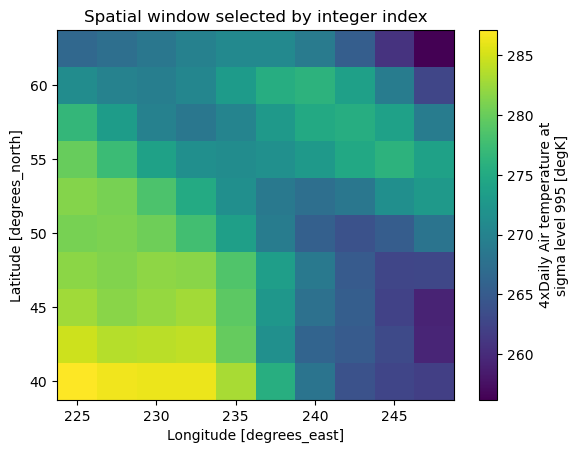

In [5]:
# Select a small spatial window (slices) from the first time step
# Note: slice(5, 15) selects indices 5 through 14
window = air.isel(time=0, lat=slice(5, 15), lon=slice(10, 20))
window.plot()
plt.title("Spatial window selected by integer index");

<div class="figure-caption-like">
Positional selection: Extracting a rectangular spatial window using row and column indices.
</div>

### .sel for label based selection

Scientific analysis is rarely defined by matrix indices; instead, it is defined by **real world parameters**. The `.sel` method uses dimension labels to automatically look up the correct indices for you.

In [6]:
# Select by exact date and coordinate values
# This is much more readable and less error prone
air.sel(time="2013-01-01", lat=40.0, lon=260.0)

<xarray.DataArray 'air' (time: 4)> Size: 32B
array([265.2, 266.2, 262.4, 267.5])
Coordinates:
  * time     (time) datetime64[ns] 32B 2013-01-01 ... 2013-01-01T18:00:00
    lat      float32 4B 40.0
    lon      float32 4B 260.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

Because coordinates are backed by an index, these lookups are highly efficient. You can also use `slice()` with `.sel` to filter data between specific geographic or temporal bounds.

In [7]:
# Select a range of longitudes and limit the output display
air.sel(lon=slice(210, 215)).head(time=1)

<xarray.DataArray 'air' (time: 1, lat: 25, lon: 3)> Size: 600B
array([[[244.1 , 243.89, 243.6 ],
        [243.39, 242.39, 241.7 ],
        [246.  , 244.39, 243.1 ],
        [265.9 , 264.7 , 263.1 ],
        [273.79, 273.  , 271.79],
        [269.  , 267.9 , 266.4 ],
        [275.6 , 275.7 , 274.5 ],
        [278.7 , 280.  , 280.1 ],
        [277.6 , 278.6 , 279.2 ],
        [278.7 , 279.5 , 280.  ],
        [279.5 , 280.1 , 280.6 ],
        [279.4 , 280.29, 281.29],
        [280.29, 282.  , 283.29],
        [282.2 , 283.79, 285.5 ],
        [284.2 , 285.5 , 287.29],
        [287.9 , 289.  , 289.9 ],
        [290.79, 291.7 , 292.29],
        [293.1 , 293.79, 293.6 ],
        [294.5 , 294.9 , 293.5 ],
        [295.4 , 294.7 , 293.2 ],
        [295.4 , 294.  , 292.9 ],
        [294.9 , 293.4 , 292.79],
        [295.5 , 294.  , 293.6 ],
        [296.1 , 295.1 , 294.6 ],
        [296.9 , 296.4 , 296.  ]]])
Coordinates:
  * time     (time) datetime64[ns] 8B 2013-01-01
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 12B 210.0 212.5 215.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Nearest neighbor lookups

In real-world Geospatial Data Science, your target coordinates (e.g., a weather station location) might not perfectly align with the center of a grid cell. While standard indexing would fail, `.sel` supports **inexact lookups** via the `method` and `tolerance` parameters.

* **`method="nearest"`**: Selects the value of the closest pixel without interpolation.
* **`tolerance`**: Limits the maximum distance for a valid match, preventing the selection of data that is too far from your target location.

In [8]:
# Find the value at a coordinate that isn't exactly in the grid
# method="nearest" finds the closest match
air.sel(lat=52.25, lon=251.89, method="nearest", tolerance=2)

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([262.7 , 263.2 , 270.9 , ..., 264.19, 265.19, 266.99], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 52.5
    lon      float32 4B 252.5
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

<div class="figure-caption-like">
The nearest neighbor lookup: Automatically snapping site coordinates to the closest available grid cell center.
</div>

```{admonition} Beyond Nearest Neighbor
:class: dropdown

**Alternative Lookup Strategies**
In addition to `nearest`, Xarray supports other methods for aligning labels with index values:
* **`pad` / `ffill`**: "Forward fills" by using the last valid index value found before the requested label.
* **`backfill` / `bfill`**: "Backward fills" by using the next valid index value found after the requested label.

**Understanding Tolerance Units**
The `tolerance` parameter uses the **same unit as the dimension coordinate** being indexed. 
* **Degrees**: If using WGS84 (EPSG:4326), `tolerance=2` represents **2 decimal degrees**.
* **Meters**: If using a metric projection (like UTM), `tolerance=2` represents **2 meters**.
* **Time**: If indexing time, the unit is a **time duration** (e.g., `pd.Timedelta("1D")`).

If you need to estimate values *between* pixels rather than choosing an existing one, use the **`.interp()`** method (covered in the resolution manipulation section).
```

### Differences from NumPy behavior

While Xarray feels like NumPy, it behaves differently when you index with multiple arrays simultaneously.

```{caution}
Positional indexing in Xarray deviates from NumPy behavior when using multiple arrays for selection.
```

In NumPy, indexing with two arrays (e.g., `arr[[0,1], [0,1]]`) performs **pointwise** indexing, returning elements at `(0,0)` and `(1,1)`. In Xarray, the default behavior is **orthogonal** (or outer) indexing. This means Xarray selects the entire **Cartesian product** of the indices, resulting in a 2D sub array rather than a 1D list of points.


### When to use which

To maintain clean and reproducible code, follow this practical rule:

* Use **`.isel`** when you care about **array positions** (e.g., the "first" or "last" element).
* Use **`.sel`** when you care about **real coordinates or dates** (e.g., "Seattle" or "2013-05-12").

These methods work identically for both `DataArray` and `Dataset` objects, allowing you to index all variables in a dataset simultaneously.

---

## 3. Slicing time

Time is arguably the most important dimension in a data cube. Xarray is exceptionally elegant here because time coordinates are treated as first class datetime objects rather than simple strings or numerical indices. This temporal awareness allows you to navigate years, months, and specific moments with high precision.

### Selecting specific moments

You can query the cube for an exact moment in time using a full timestamp string. In a 3D cube, selecting one moment across the time dimension returns a 2D spatial slice (a map).

In [9]:
# Select a specific hour on New Year's Day
air.sel(time="2013-01-01 06:00")

<xarray.DataArray 'air' (lat: 25, lon: 53)> Size: 11kB
array([[242.1 , 242.7 , 243.1 , ..., 232.  , 233.6 , 235.8 ],
       [243.6 , 244.1 , 244.2 , ..., 231.  , 232.5 , 235.7 ],
       [253.2 , 252.89, 252.1 , ..., 230.8 , 233.39, 238.5 ],
       ...,
       [296.4 , 295.9 , 296.2 , ..., 295.4 , 295.1 , 294.79],
       [296.2 , 296.7 , 296.79, ..., 295.6 , 295.5 , 295.1 ],
       [296.29, 297.2 , 297.4 , ..., 296.4 , 296.4 , 296.6 ]],
      shape=(25, 53))
Coordinates:
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
    time     datetime64[ns] 8B 2013-01-01T06:00:00
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Natural shorthand for months and years

One of Xarray's most convenient features is its ability to interpret partial datetime strings. This allows you to grab entire blocks of data without needing to define start and end dates manually.

In [10]:
# Extract all data for the year 2014
air.sel(time="2014")

# Extract all data for a specific month
air.sel(time="2013-05").head(time=1)

<xarray.DataArray 'air' (time: 1, lat: 25, lon: 53)> Size: 11kB
array([[[259.2 , 259.29, 259.1 , ..., 251.39, 252.6 , 254.3 ],
        [257.1 , 257.1 , 256.8 , ..., 250.  , 251.89, 254.7 ],
        [257.9 , 257.4 , 256.8 , ..., 252.7 , 254.89, 258.4 ],
        ...,
        [298.5 , 298.  , 297.29, ..., 296.7 , 296.29, 295.79],
        [298.5 , 298.2 , 297.5 , ..., 297.1 , 296.79, 296.1 ],
        [298.79, 298.5 , 297.9 , ..., 296.9 , 296.79, 296.4 ]]],
      shape=(1, 25, 53))
Coordinates:
  * time     (time) datetime64[ns] 8B 2013-05-01
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Temporal intervals with slice

To select a continuous range of time, use the Python `slice` function. This is the standard way to isolate specific seasons or study periods.

In [11]:
# Select a window from May to mid October
air.sel(time=slice("2013-05-01", "2013-10-15")).head(time=1)

<xarray.DataArray 'air' (time: 1, lat: 25, lon: 53)> Size: 11kB
array([[[259.2 , 259.29, 259.1 , ..., 251.39, 252.6 , 254.3 ],
        [257.1 , 257.1 , 256.8 , ..., 250.  , 251.89, 254.7 ],
        [257.9 , 257.4 , 256.8 , ..., 252.7 , 254.89, 258.4 ],
        ...,
        [298.5 , 298.  , 297.29, ..., 296.7 , 296.29, 295.79],
        [298.5 , 298.2 , 297.5 , ..., 297.1 , 296.79, 296.1 ],
        [298.79, 298.5 , 297.9 , ..., 296.9 , 296.79, 296.4 ]]],
      shape=(1, 25, 53))
Coordinates:
  * time     (time) datetime64[ns] 8B 2013-05-01
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

```{admonition} Slices are inclusive
:class: note

In standard Python lists, the "stop" value of a slice is exclusive. However, in Xarray label based indexing, both the start and stop labels are **inclusive**. This ensures that if you slice to the end of a month, those final observations are preserved.
```

### Components and fancy temporal indexing

Behind the scenes, Xarray provides a `.dt` accessor that allows you to reach into the datetime objects and extract specific components like `month`, `day`, `year`, or even `season`. 

This enables "fancy indexing" where you select data based on a condition rather than a continuous range. For example, if you want to perform a climatological study on a specific month across multiple years, you can filter the cube by the month component.

In [12]:
# Select all data points from July across every year in the record
july_data = air.sel(time=air.time.dt.month == 7)

# Check the resulting timestamps
july_data.time

<xarray.DataArray 'time' (time: 248)> Size: 2kB
array(['2013-07-01T00:00:00.000000000', '2013-07-01T06:00:00.000000000',
       '2013-07-01T12:00:00.000000000', ..., '2014-07-31T06:00:00.000000000',
       '2014-07-31T12:00:00.000000000', '2014-07-31T18:00:00.000000000'],
      shape=(248,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2kB 2013-07-01 ... 2014-07-31T18:00:00
Attributes:
    standard_name:  time
    long_name:      Time

This logic also works for grouping by the season component (`DJF`, `MAM`, `JJA`, `SON`), providing a bridge to the advanced temporal aggregation and seasonal analysis covered later in this course.

---

### 4. Slicing space

Spatial selection mirrors the logic of temporal slicing but operates on the horizontal axes of the cube. By using coordinate labels instead of axis numbers, you avoid the mental overhead of remembering if "axis 0" refers to latitude or longitude.

### Horizontal cross sections

The simplest spatial slice is a single row or column. This reduces a 3D cube into a 2D "vertical" slice of time and space.

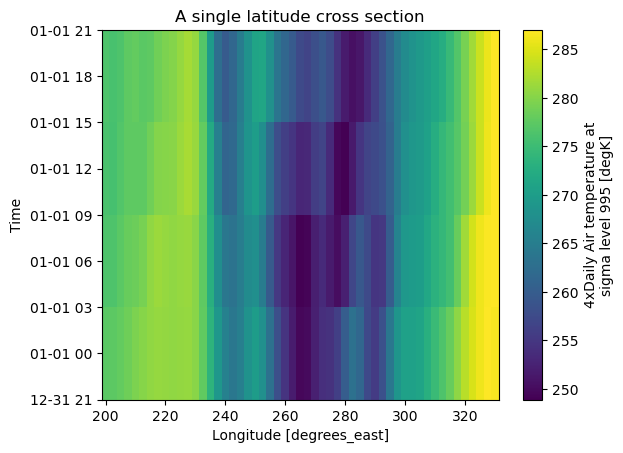

In [13]:
# Extract one latitude row through all longitudes for a specific time
# This results in a 2D array (time, lon)
air.sel(time="2013-01-01").isel(lat=10).plot()
plt.title("A single latitude cross section");

### Bounding boxes

A rectangular subset, or bounding box, is the most common way to isolate a specific study area. You define these windows using the `slice()` function within `.sel()`.

Text(0.5, 1.0, 'Regional bounding box subset')

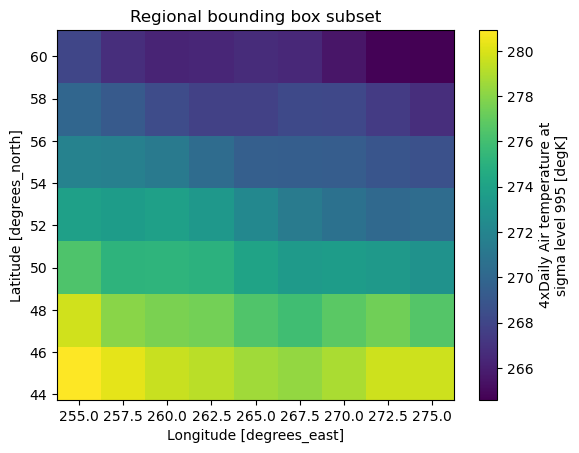

In [14]:
# Define a geographic subset for Central Canada
# Latitude in this dataset is stored in descending order (North to South)
# Longitude 255-275 corresponds roughly to 105W-85W
subset = air.sel(lon=slice(255, 275), lat=slice(60, 45))
subset.mean(dim="time").plot()
plt.title("Regional bounding box subset")

<div class="figure-caption-like">
Slicing space: Defining a geographic bounding box using physical coordinates.
</div>

```{admonition} Respect the coordinate order
:class: caution

When using `slice()` with `.sel()`, the range must match the direction of the underlying coordinate values. 
* If latitude decreases (e.g., 75 to 15), use `slice(75, 15)`.
* If latitude increases (e.g., 15 to 75), use `slice(15, 75)`.
A slice that goes against the index order will return an empty object.
```

### Point extraction

Selecting a single cell by its coordinates is the spatial equivalent of selecting one exact timestamp. If you do not specify a time constraint, this operation isolates a location across the entire temporal dimension, effectively turning a spatial cube into a 1D time series.

In [15]:
# Isolate one location across all time steps
# This returns a 1D DataArray of temperature over time
specific_station = air.sel(lat=50.0, lon=260.0)
specific_station

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([254.6 , 252.89, 256.  , ..., 258.69, 260.39, 261.49], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 50.0
    lon      float32 4B 260.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Reusable study areas

In professional Geospatial Data Science workflows, it is best practice to define your study area once and persist it as a new object. This makes your code more readable and prevents you from accidentally running heavy calculations on the full global dataset when you only need a local subset.

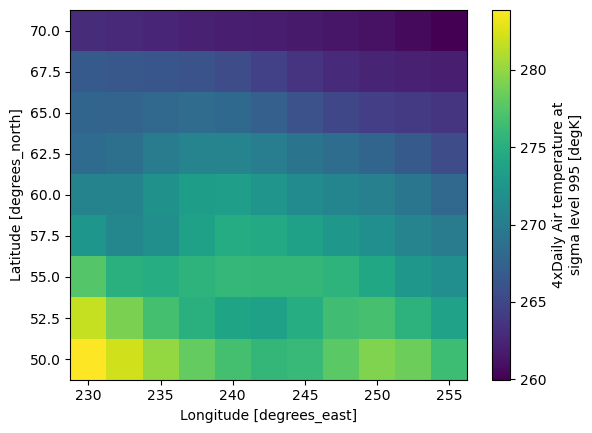

In [16]:
# Define and persist a regional subset for Western Canada
western_canada = air.sel(lon=slice(230, 255), lat=slice(70, 50))

# All subsequent analysis now uses the smaller, more efficient object
western_canada.mean(dim="time").plot();

By persisting subsets, you move from general exploration to a focused analysis of a specific geographic region.

---

## 5. Conditional selection and masking

While `.sel()` and `.isel()` navigate the cube using its "outer" labels (where the data is), you often need to interrogate the "inner" values (what the data says). This is the role of **boolean masking**, a technique that enables filtering values based on specific scientific criteria rather than just their location.

### The concept of a boolean mask

A boolean mask is a binary array of the same shape as your data, containing only `True` or `False` values. It acts as a spatial filter: when applied to a DataArray, only the elements corresponding to `True` are retained.

### Filtering with `.where()`

Xarray provides the `.where()` method to apply these masks. Unlike coordinate selection, `.where()` typically preserves the **shape** of the original data. Values that do not meet the condition are replaced with a "mask" value—by default, `NaN` (Not a Number).

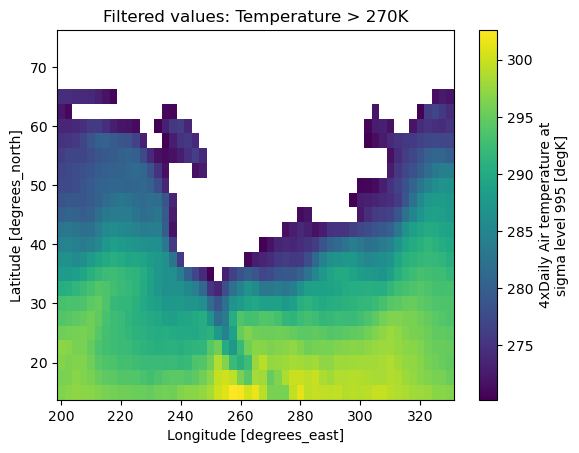

In [17]:
# Keep only "warm" pixels above 270 Kelvin
warm_mask = air > 270
warm_data = air.where(warm_mask)

# Visualize the first time step
warm_data.isel(time=0).plot()
plt.title("Filtered values: Temperature > 270K");

<div class="figure-caption-like">
Boolean masking: Filtering the data cube based on a value condition rather than a location.
</div>

If you need to replace masked values with a specific placeholder instead of `NaN`, you can provide a second argument:

In [18]:
# Replace everything else with a specific NoData value
air.where(air > 270, -9999).head(time=1)

<xarray.DataArray 'air' (time: 1, lat: 25, lon: 53)> Size: 11kB
array([[[-9999.  , -9999.  , -9999.  , ..., -9999.  , -9999.  ,
         -9999.  ],
        [-9999.  , -9999.  , -9999.  , ..., -9999.  , -9999.  ,
         -9999.  ],
        [-9999.  , -9999.  , -9999.  , ..., -9999.  , -9999.  ,
         -9999.  ],
        ...,
        [  296.6 ,   296.2 ,   296.4 , ...,   295.4 ,   295.1 ,
           294.7 ],
        [  295.9 ,   296.2 ,   296.79, ...,   295.9 ,   295.9 ,
           295.2 ],
        [  296.29,   296.79,   297.1 , ...,   296.9 ,   296.79,
           296.6 ]]], shape=(1, 25, 53))
Coordinates:
  * time     (time) datetime64[ns] 8B 2013-01-01
  * lat      (lat) float32 100B 75.0 72.5 70.0 67.5 65.0 ... 22.5 20.0 17.5 15.0
  * lon      (lon) float32 212B 200.0 202.5 205.0 207.5 ... 325.0 327.5 330.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Clipping with `drop=True`

By default, `.where()` keeps the entire grid, even if large portions are empty. To shrink the cube to the smallest possible bounding box that contains your valid data, use the `drop=True` parameter. This is particularly useful for "clipping" a dataset to a specific feature or anomaly.

In [19]:
# Mask and immediately clip the array to the valid area
arctic_only = air.where(ds.lat > 60, drop=True)
print(f"Original shape: {air.shape}")
print(f"Clipped shape:  {arctic_only.shape}")

Original shape: (2920, 25, 53)
Clipped shape:  (2920, 6, 53)


### Complex logical conditions

You can specify multiple masking conditions within a single `.where()` statement using bitwise operators: `&` (and) and `|` (or). This allows for the selection of specific value ranges or complex geographic windows.

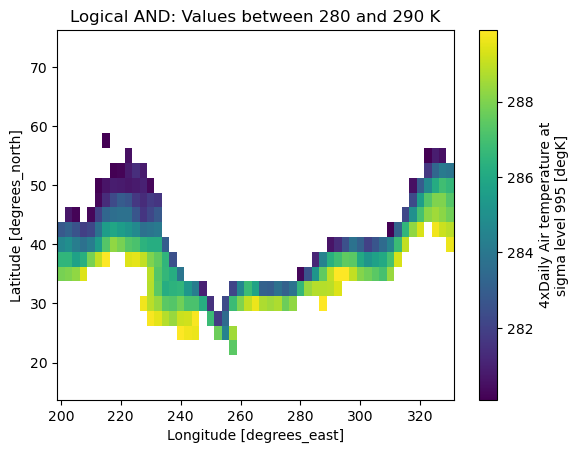

In [20]:
# Select temperatures between 280K and 290K
moderate_range = air.where((air > 280) & (air < 290), drop=True)
moderate_range.isel(time=0).plot()
plt.title("Logical AND: Values between 280 and 290 K");

### Discrete selection with `.isin()`

When your data contains discrete categories rather than continuous measurements—such as land cover types or quality status flags—the `.isin()` method is the preferred tool. It allows you to check for a list of specific values simultaneously.

In [21]:
# Conceptual example: selecting specific data quality flags
# Assume we have a DataArray of flags where 1 and 2 are "good"
# da_masked = air.where(flags.isin([1, 2]), drop=True)

### Strategic considerations for workflows

Masking is central to professional Geospatial Data Science. Typical applications include:
* **Cloud Removal:** Masking pixels flagged as cloudy in satellite metadata.
* **Hydrological Modeling:** Masking out water bodies or oceans from a terrain analysis.
* **Anomaly Detection:** Isolating only the most extreme temperature or precipitation values.

```{admonition} Performance Note
:class: warning
When performing repeated operations, conditional indexing via `where()` is significantly slower than label-based indexing via `sel()`. Whenever possible, use `sel()` to define your spatial and temporal boundaries first, then use `where()` for value-based filtering.
```

### Comparison: Selection vs Masking

| Feature | `.sel()` / `.isel()` | `.where()` |
| :--- | :--- | :--- |
| **Logic** | Query by labels/indices (Where is it?) | Query by values (What is it?) |
| **Result** | Always a smaller subset (slice) | Usually the same shape, just masked |
| **Missing Data** | None | Replaces rejected cells with `NaN` |
| **Primary Use** | Navigation and subsetting | Thresholding and data cleaning |

---

## 6. Extracting a point time series

Extracting a time series is the bridge between spatial maps and temporal trends. While maps show the distribution of a variable at one moment, a time series reveals how a specific location evolves throughout the entire duration of the dataset.

### From 3D cube to 1D signal
In a data cube with dimensions `(time, lat, lon)`, selecting one specific coordinate reduces the spatial dimensions to single values. This transforms the 3D structure into a one-dimensional **signal** indexed by time.

In [22]:
# Select a specific coordinate point
# This isolates one 'pixel' through the entire temporal dimension
point_ts = air.sel(lat=50.0, lon=260.0)
point_ts

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([254.6 , 252.89, 256.  , ..., 258.69, 260.39, 261.49], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 50.0
    lon      float32 4B 260.0
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

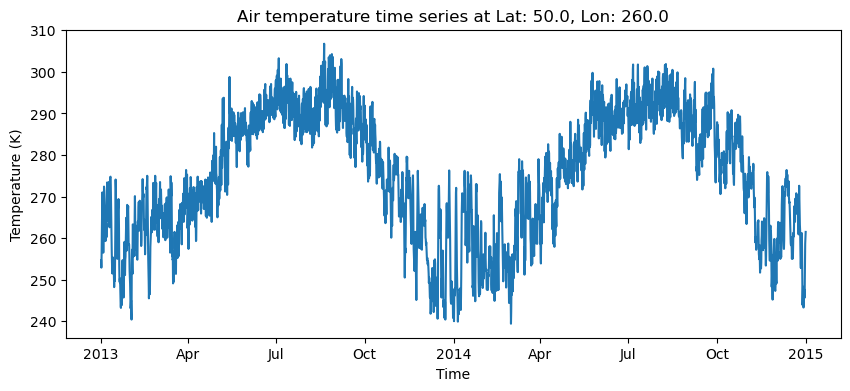

In [23]:
# Rapid validation of the temporal signal
point_ts.plot(figsize=(10, 4))
plt.title("Air temperature time series at Lat: 50.0, Lon: 260.0")
plt.ylabel("Temperature (K)");

### Handling coordinate grid mismatches
In real-world Geospatial Data Science, the coordinates of your observation sites (e.g., weather stations or cities) rarely align perfectly with the centers of a raster grid. If you attempt to select a coordinate that does not exist exactly in the index, Xarray will raise an error unless you specify a lookup strategy.

The **`method="nearest"`** parameter tells Xarray to find the single closest available grid cell.

In [24]:
# Find the value at a coordinate that is not exactly in the grid
# 'nearest' picks the center of the closest pixel
point_ts_nearest = air.sel(lat=51.2, lon=261.3, method="nearest")
point_ts_nearest

<xarray.DataArray 'air' (time: 2920)> Size: 23kB
array([251.8 , 251.  , 254.7 , ..., 257.49, 259.89, 261.59], shape=(2920,))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
    lat      float32 4B 50.0
    lon      float32 4B 262.5
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

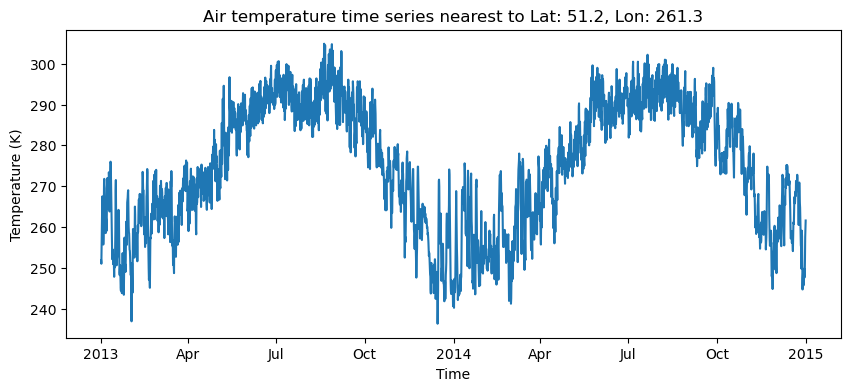

In [25]:
# Rapid validation of the temporal signal
point_ts_nearest.plot(figsize=(10, 4))
plt.title("Air temperature time series nearest to Lat: 51.2, Lon: 261.3")
plt.ylabel("Temperature (K)");

### Continuous estimation with interpolation
While nearest neighbor selection is fast and preserves original data values, it can lead to "blocky" results if you are sampling many points close together. To look at inferred values **between** existing grid cells, you should use the **`.interp()`** method.

Instead of snapping to the nearest pixel, interpolation uses neighboring observations (typically via a `linear` or `cubic` method) to estimate the value at your exact requested location.

In [30]:
# Estimate the value between grid cells using linear interpolation
# This requires the 'scipy' library
point_ts_interp = air.interp(lat=51.2, lon=261.3, method="linear")

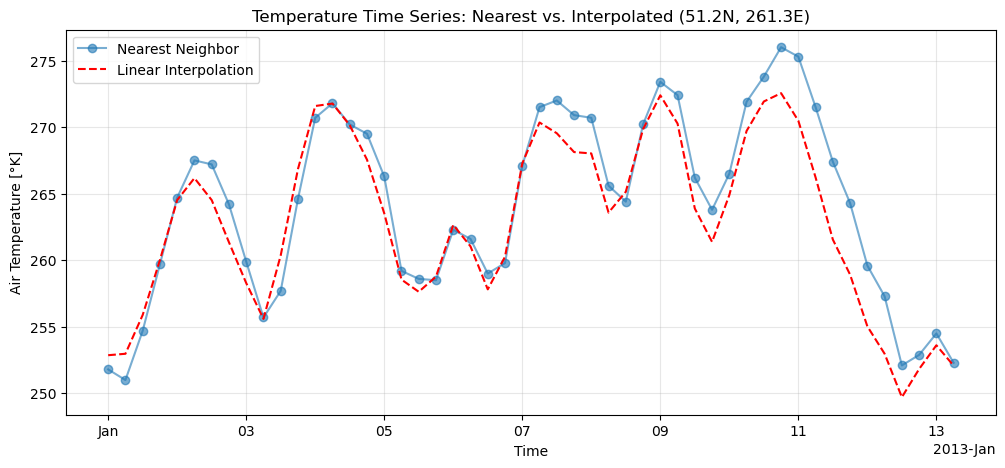

In [31]:
import matplotlib.pyplot as plt

# Plot both the nearest-neighbor and interpolated time series for comparison
plt.figure(figsize=(12, 5))

# Limit to a small window of time to see the interpolation details clearly
point_ts_nearest.isel(time=slice(0, 50)).plot(
    label="Nearest Neighbor", marker="o", alpha=0.6
)
point_ts_interp.isel(time=slice(0, 50)).plot(
    label="Linear Interpolation", linestyle="--", color="red"
)

plt.title("Temperature Time Series: Nearest vs. Interpolated (51.2N, 261.3E)")
plt.ylabel("Air Temperature [°K]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Visualizing temporal trends
One of the most efficient features of Xarray is its ability to automatically detect the dimensions of a result. Because the extracted object is 1D, calling `.plot()` immediately generates a line chart with correctly formatted time labels.

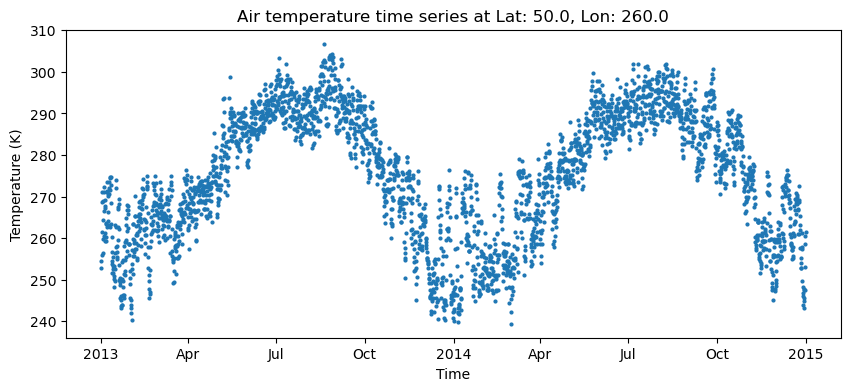

In [32]:
# Rapid validation of the temporal signal using a scatter plot
point_ts.plot.line(marker="o", linestyle="none", markersize=2, figsize=(10, 4))
plt.title("Air temperature time series at Lat: 50.0, Lon: 260.0")
plt.ylabel("Temperature (K)");

<div class="figure-caption-like">
From map to series: A temporal signal extracted from a single pixel through the entire time dimension.
</div>

By selecting one spatial location, you have successfully "interrogated" the 3D cube to extract a continuous signal ready for trend analysis, seasonality checks, or climatological modeling.

---

## 7. Sampling multiple locations and regional summaries

While single point extraction is a vital diagnostic tool, scientific analysis often requires comparing several distinct sites or generating a representative summary for an entire geographic area. This section moves from simple subsetting to **pointwise indexing** and **spatial reductions**.

### Vectorized pointwise indexing

In professional workflows, you often need to sample the data cube at a specific collection of coordinates (for example, at the locations of several weather stations or urban centers). 

Xarray handles this through **Vectorized Indexing**. If you provide selection coordinates as Xarray DataArrays that share a dimension name (such as `"points"`), Xarray will extract exactly those pairs rather than a 2D rectangular grid. This is significantly more efficient than looping through locations one by one.

In [33]:
import pandas as pd
import xarray as xr

# Define coordinates for Fairbanks, Vancouver, and Oaxaca
city_coords = pd.DataFrame(
    {
        "city": ["Fairbanks", "Montreal", "Oaxaca"],
        "lat": [64.8, 45.5, 17.1],
        "lon": [212.2, 286.4, 263.3],
    }
)

# Convert to xarray arrays
x_cities = xr.DataArray(
    city_coords["lon"], dims="city", coords={"city": city_coords["city"]}
)
y_cities = xr.DataArray(
    city_coords["lat"], dims="city", coords={"city": city_coords["city"]}
)

# Sample the data
city_samples = air.sel(lon=x_cities, lat=y_cities, method="nearest")
city_samples

<xarray.DataArray 'air' (time: 2920, city: 3)> Size: 70kB
array([[273.  , 267.  , 294.1 ],
       [268.  , 270.2 , 290.5 ],
       [267.79, 266.29, 288.4 ],
       ...,
       [274.69, 256.09, 290.29],
       [274.99, 257.39, 288.09],
       [272.89, 262.89, 292.09]], shape=(2920, 3))
Coordinates:
  * time     (time) datetime64[ns] 23kB 2013-01-01 ... 2014-12-31T18:00:00
  * city     (city) object 24B 'Fairbanks' 'Montreal' 'Oaxaca'
    lat      (city) float32 12B 65.0 45.0 17.5
    lon      (city) float32 12B 212.5 287.5 262.5
Attributes:
    long_name:     4xDaily Air temperature at sigma level 995
    units:         degK
    precision:     2
    GRIB_id:       11
    GRIB_name:     TMP
    var_desc:      Air temperature
    dataset:       NMC Reanalysis
    level_desc:    Surface
    statistic:     Individual Obs
    parent_stat:   Other
    actual_range:  [185.16 322.1 ]

### Comparing site time series

Because the resulting object preserves the new `"points"` dimension, you can immediately visualize the differences between your selected locations using a line plot. This allows for a rapid assessment of whether different sites follow similar temporal trends.

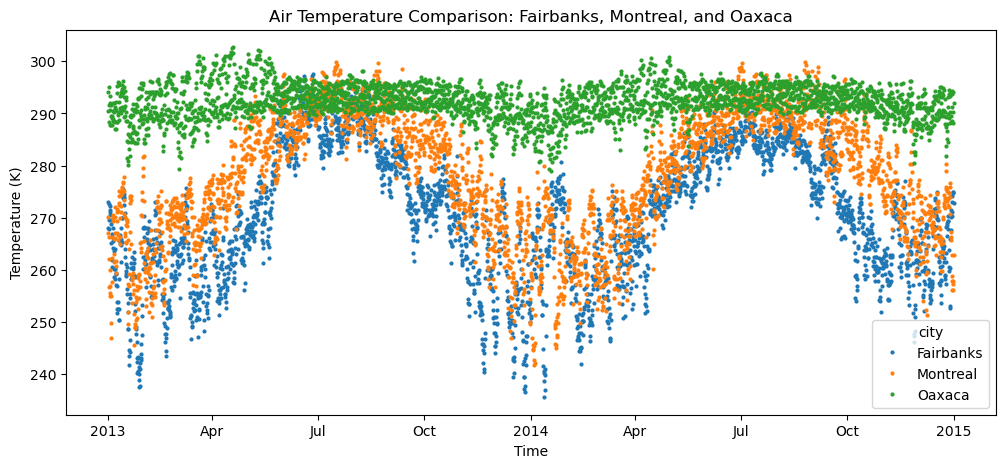

In [ ]:
# Plot the comparison
city_samples.plot.line(
    marker="o", linestyle="none", markersize=2, x="time", hue="city", figsize=(12, 5)
)
plt.title("Air Temperature Comparison: Fairbanks, Montreal, and Oaxaca")
plt.ylabel("Temperature (K)")
plt.show()

<div class="figure-caption-like">
Comparative analysis: Plotting several extracted point time series together to identify regional trends.
</div>

### Regional summaries and reductions

Sometimes individual pixels are too noisy or specific for your analysis. In these cases, you want to reduce a 3D spatial subset into a single representative 1D time series for a region.

This process is called a **Spatial Reduction**. By calculating the mean across both horizontal dimensions (`lat` and `lon`), you effectively collapse the spatial variability into a single regional signal.

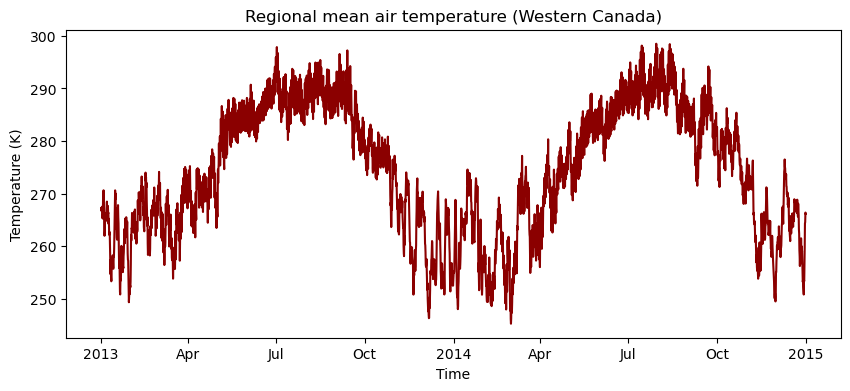

In [36]:
# 1. Define a focused geographic study area (bounding box)
region = air.sel(lon=slice(235, 255), lat=slice(60, 50))

# 2. Reduce the spatial dimensions to their mean value
region_mean = region.mean(dim=["lat", "lon"])

# 3. Visualize the smoothed regional trend
region_mean.plot(figsize=(10, 4), color="darkred")
plt.title("Regional mean air temperature (Western Canada)")
plt.ylabel("Temperature (K)");

```{admonition} Why reduce dimensions?
:class: tip

Reducing a 3D cube to a 1D time series is a fundamental pattern in climate science. It allows you to transform massive amounts of high resolution data into a simple, interpretable indicator of regional environmental change.
```

### Point, box, and polygon sampling

In this chapter, we have focused on point sampling (zero dimensional) and bounding box sampling (two dimensional rectangular). These tools cover the vast majority of exploratory sampling tasks. 

For more complex analysis involving irregular geographic shapes (like political boundaries or watersheds), you will eventually use **Zonal Statistics**. This requires an additional step of rasterizing your polygons to align them with the cube, a topic we will explore in the next section on integrating vector and raster data.

---

## 8. Exercise: Scale Comparison

In this exercise, you will evaluate how well a single observation site represents its broader surrounding region. This task requires combining point selection, spatial slicing, and dimension reduction.

### Task

1.  **Ingestion:** Open the `air_temperature` tutorial dataset and extract the `air` variable.
2.  **Point Sampling:** Select the coordinate at `lat=40.0` and `lon=260.0` to extract its full time series.
3.  **Regional Slicing:** Define a spatial bounding box centered around that same location using `lon=slice(255, 265)` and `lat=slice(45, 35)`. 
4.  **Reduction:** Calculate the mean air temperature of that box for every time step.
5.  **Visualization:** Plot both the point time series and the regional mean on a single figure with appropriate labels and a legend.
6.  **Interpretation:** Write two short sentences comparing the behavior of the point and the regional mean. Consider which series is more stable and why.

:::{tip}
Check the coordinate order of your dataset before slicing. Because latitude values in this dataset decrease from North to South, your `slice(45, 35)` must follow that descending order to return data.
:::

### Starter code

In [37]:
import xarray as xr
import matplotlib.pyplot as plt

# Load the tutorial dataset
ds = xr.tutorial.open_dataset("air_temperature")
air = ds["air"]

# 1. Extract the point time series
# point_ts = ...

# 2. Extract the regional mean
# region_mean = ...

# 3. Plot the comparison
# ...

````{admonition} Sample solution
:class: dropdown

```{code-cell} python
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.tutorial.open_dataset("air_temperature")
air = ds["air"]

# Point time series extraction using label-based selection
point_ts = air.sel(lat=40.0, lon=260.0)

# Bounding box selection and spatial mean reduction
# We reduce 'lat' and 'lon' simultaneously to get a 1D time series
region = air.sel(lon=slice(255, 265), lat=slice(45, 35))
region_mean = region.mean(dim=["lat", "lon"])

# Plotting the results together
fig, ax = plt.subplots(figsize=(10, 4))
point_ts.plot(ax=ax, label="Single Point (40N, 260E)", alpha=0.6)
region_mean.plot(ax=ax, label="Regional Mean (10° Box)", linewidth=2)

ax.set_title("Point Time Series vs. Regional Mean")
ax.set_ylabel("Temperature (K)")
ax.legend()
plt.show()
```

:::{figure} images/10_sampling_exercise_result.png
:alt: A line plot comparing a jagged single-point temperature series with a smoother regional average series.
:width: 800px
:align: center

*Exercise result: Comparing local pixel variability with a spatially smoothed regional average.*
:::

**Interpretation**
The point time series is more variable because it reflects the specific atmospheric fluctuations of a single grid cell. The regional mean is smoother because it averages over many neighboring cells, which cancels out local extremes and reduces overall noise in the signal.
````

```{admonition} Reflection
:class: note
Point extraction identifies exactly what happens at a specific location over time, whereas regional averaging captures the broader environmental trend of an entire area. Understanding this difference is critical when comparing satellite observations to field data.
```

---

## 9. Summary

Sampling is where the data cube transforms from a collection of observations into a targeted analytical tool. In this chapter, you moved from passive inspection to active interrogation of the cube.

You learned that Xarray supports three primary paths for navigating data:
1. **Position based selection (`.isel`)**: Navigating the cube using 0-based integer indices, serving as the direct successor to NumPy indexing.
2. **Label based selection (`.sel`)**: Querying the cube using meaningful, human-readable labels like specific dates or physical coordinates.
3. **Condition based masking (`.where`)**: Filtering the data based on internal values, such as cloud flags or temperature thresholds, rather than its location.

Beyond basic selection, you also learned how to:
* **Slice time and space**: Use partial date strings or coordinate ranges with `slice()` to isolate specific intervals and geographic bounding boxes.
* **Perform nearest neighbor lookups**: Handle mismatches between your study coordinates and the raster grid using the `nearest` method and distance tolerances.
* **Extract point time series**: Reduce a 3D cube into a 1D temporal signal for site-specific analysis.
* **Leverage vectorized indexing**: Sample multiple distinct locations simultaneously by providing coordinate arrays with shared dimension names.
* **Generate regional summaries**: Reduce complex spatial subsets into interpretable indicators by calculating means across horizontal dimensions.

The key lesson of this chapter is **analytical clarity**. By using named dimensions and coordinates, Xarray allows you to move through a cube in a way that matches how scientists actually think about their data: by dates, places, regions, and conditions, rather than by anonymous integer axes.

Now that you can isolate exactly the right data, the next chapter covers how to combine, align, and perform map algebra between multiple different cubes to build complex Geospatial Data Science workflows.